#  Unidad 2 — Machine Learning aplicado a E-commerce
## Selección, Entrenamiento, Evaluación y Despliegue de Modelos

**TecNM Campus Apatzingán | Ingeniería en Sistemas Computacionales**  
**Curso:** De la Ciencia de Datos al Desarrollo de Modelos de ML y Deep Learning  
**Sesión:** 2 de 4 · Duración: 6 horas  
**Instructor:** Dr. Omar Jehovani López Orozco

---

###  Objetivo de esta libreta
Al terminar esta sesión serás capaz de:
1. Seleccionar el algoritmo de clasificación adecuado justificando la elección.
2. Construir un **Pipeline reproducible** que evite fuga de datos entre entrenamiento y prueba.
3. Evaluar modelos con métricas apropiadas para datos desbalanceados.
4. Interpretar un árbol de decisión e importancia de variables.
5. Aplicar validación cruzada y búsqueda de hiperparámetros.
6. Segmentar visitantes con K-Means y visualizarlos en 2D con PCA.
7. Exportar el pipeline y desplegarlo como **API REST con FastAPI**.

---

###  Cómo usar esta libreta
- Ejecuta las celdas **en orden de arriba hacia abajo**. Nunca saltes una celda.
- Cada bloque de código tiene comentarios que explican **qué hace cada línea**.
- Después de cada paso encontrarás celdas de reflexión: **escribe tus respuestas** antes de continuar.
- Si una celda da error, lee el mensaje: casi siempre es una dependencia no instalada o una celda anterior que no se ejecutó.

---

###  Mapa de la sesión

| Paso | Tema | Tiempo estimado |
|------|------|----------------|
| 1 | Instalación y carga de datos | 15 min |
| 2 | Exploración inicial | 20 min |
| 3 | Preparación y pipeline | 20 min |
| 4 | Taxonomía y selección de modelos | 20 min |
| 5 | Entrenamiento y evaluación comparativa | 30 min |
| 6 | Interpretabilidad | 20 min |
| 7 | Validación rigurosa e hiperparámetros | 30 min |
| 8 | Aprendizaje no supervisado (K-Means + PCA) | 30 min |
| 9 | Exportación con MLflow y Pickle | 15 min |
| 10 | Despliegue con FastAPI | 30 min |


---
## 💭 Reflexión inicial (antes de ejecutar cualquier celda)

> Tómate 5 minutos para responder estas preguntas en la celda de texto siguiente.  
> No hay respuestas incorrectas; el objetivo es activar tu intuición antes de ver los datos.

1. Si fueras responsable de una tienda en línea, ¿qué te interesaría predecir antes de que una persona abandone el sitio?
2. ¿Qué riesgos tendría entrenar un modelo cuando una clase aparece mucho más que la otra?
3. ¿Qué diferencia esperas entre un modelo fácil de explicar (como un árbol) y uno más complejo pero con mayor desempeño (como XGBoost)?


### ✏️ Mis respuestas (reflexión inicial)

*Escribe aquí tus respuestas...*

1. ...
2. ...
3. ...


---
## Paso 1 — Instalación de dependencias y carga del dataset

### ¿Por qué este paso es importante?
Antes de escribir una sola línea de modelo necesitamos dos cosas:
- Un **entorno reproducible**: las mismas librerías, las mismas versiones.
- Los **datos en crudo**, sin modificar, tal como los publica la fuente original.

#### ¿Qué dataset usamos?
**Online Shoppers Purchasing Intention** (UCI Machine Learning Repository, ID 468).  
Contiene **12,330 sesiones de navegación** de una tienda en línea real.  
Cada fila representa una sesión de usuario con 17 variables y una variable objetivo:  
`Revenue = True` si la sesión terminó en compra, `False` si no.

#### Librería `ucimlrepo`
Es el cliente oficial de UCI para descargar datasets directamente en Python sin descargar archivos manualmente. `fetch_ucirepo(id=468)` descarga el dataset y lo separa en `features` y `targets`.


In [ ]:
# ==========================================
# PASO 1A — INSTALACIÓN DE DEPENDENCIAS
# ==========================================
# Ejecuta esta celda primero. Puede tardar 1-2 minutos en Colab.
# El flag -q suprime la mayoría de la salida para que no inunde la pantalla.

!pip -q install --upgrade mlflow cryptography pyopenssl
!pip -q install ucimlrepo xgboost fastapi uvicorn nest_asyncio pyngrok

print("✅ Dependencias instaladas correctamente.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/13

In [ ]:
# ==========================================
# PASO 1B — IMPORTS Y CONFIGURACIÓN DEL ENTORNO
# ==========================================
# Importamos todas las librerías que necesitaremos durante toda la sesión.
# Es buena práctica importarlas todas al inicio para detectar problemas de inmediato.

import warnings
warnings.filterwarnings('ignore')  # Suprime advertencias no críticas para mantener la salida limpia

import json      # Para serializar el payload de prueba de la API
import pickle    # Para guardar/cargar el modelo entrenado en disco
from pathlib import Path  # Manejo de rutas de archivos de forma portable

# ── Librerías numéricas y de datos ──
import numpy as np      # Operaciones numéricas de bajo nivel
import pandas as pd     # Manejo de DataFrames (tablas de datos)

# ── Visualización ──
import matplotlib.pyplot as plt  # Gráficas básicas
import seaborn as sns            # Gráficas estadísticas de alto nivel

# ── Carga del dataset desde UCI ──
from ucimlrepo import fetch_ucirepo

# ── Scikit-learn: el núcleo de Machine Learning ──
from sklearn.model_selection import (
    train_test_split,      # Dividir datos en entrenamiento y prueba
    cross_val_score,       # Validación cruzada
    StratifiedKFold,       # K-Fold que preserva proporción de clases
    RandomizedSearchCV     # Búsqueda aleatoria de hiperparámetros
)
from sklearn.compose import ColumnTransformer   # Aplicar transformaciones distintas por tipo de columna
from sklearn.pipeline import Pipeline           # Encadenar pasos de preprocesamiento + modelo
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # Codificación y escalamiento
from sklearn.impute import SimpleImputer         # Imputación de valores faltantes
from sklearn.metrics import (
    accuracy_score,          # Proporción de predicciones correctas
    precision_score,         # De los que predije positivo, ¿cuántos realmente lo son?
    recall_score,            # De los positivos reales, ¿cuántos detecté?
    f1_score,                # Media armónica de precision y recall
    roc_auc_score,           # Área bajo la curva ROC (mide discriminación global)
    confusion_matrix,        # Tabla de verdaderos/falsos positivos/negativos
    ConfusionMatrixDisplay,  # Visualización de la matriz de confusión
    RocCurveDisplay,         # Visualización de curvas ROC
    classification_report    # Reporte completo de clasificación por clase
)
from sklearn.tree import DecisionTreeClassifier, plot_tree   # Árbol de decisión
from sklearn.ensemble import RandomForestClassifier           # Bosque aleatorio
from sklearn.cluster import KMeans    # Agrupamiento no supervisado
from sklearn.decomposition import PCA # Reducción de dimensionalidad

# ── XGBoost: Gradient Boosting de alto rendimiento ──
from xgboost import XGBClassifier

# ── Configuración de estilo para todas las gráficas ──
sns.set_theme(style='whitegrid')         # Fondo blanco con rejilla gris
plt.rcParams['figure.figsize'] = (10, 4) # Tamaño por defecto de las figuras
pd.set_option('display.max_columns', 80) # Mostrar hasta 80 columnas en tablas

print("✅ Todas las librerías cargadas correctamente.")
print("   NumPy:", np.__version__)
print("   Pandas:", pd.__version__)


✅ Todas las librerías cargadas correctamente.
   NumPy: 2.0.2
   Pandas: 2.2.2


In [ ]:
# ==========================================
# PASO 1C — CARGA DEL DATASET DESDE UCI
# ==========================================
# fetch_ucirepo descarga el dataset directamente desde el repositorio de UCI.
# El parámetro id=468 identifica al dataset "Online Shoppers Purchasing Intention".
# Si la descarga falla, verifica que Colab tenga conexión a internet.

online_shoppers = fetch_ucirepo(id=468)

# Separamos features (X) y targets (y) tal como los entrega UCI
X_raw = online_shoppers.data.features.copy()  # 17 columnas predictoras
y_raw = online_shoppers.data.targets.copy()   # 1 columna objetivo: Revenue

# Unimos todo en un solo DataFrame para la exploración inicial
df = pd.concat([X_raw, y_raw], axis=1)

print(f"✅ Dataset cargado: {df.shape[0]:,} sesiones × {df.shape[1]} columnas")
print()
print("Primeras 5 filas (head):")
display(df.head())

print("\nÚltimas 5 filas (tail):")
display(df.tail())


✅ Dataset cargado: 12,330 sesiones × 18 columnas

Primeras 5 filas (head):


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



Últimas 5 filas (tail):


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


---
## Paso 2 — Exploración inicial del dataset

### ¿Por qué explorar antes de modelar?
Un modelo entrenado sobre datos que no entiendes es una **caja negra doble**: no entiendes los datos ni el modelo.  
La exploración nos ayuda a:
- Detectar valores faltantes o tipos de dato incorrectos.
- Conocer la distribución de la variable objetivo (**¿está balanceada?**).
- Formular hipótesis sobre qué variables podrían ser más predictivas.

### Glosario de conceptos de esta sección

| Concepto | Significado |
|----------|-------------|
| **Desbalance de clases** | Una clase aparece mucho más que la otra. Aquí, ~84 % de sesiones NO terminan en compra. |
| **Accuracy engañosa** | Con clases desbalanceadas, un modelo que siempre dice "no compra" obtiene ~84 % de accuracy sin aprender nada útil. |
| **Precision** | De las sesiones que el modelo predice como "compra", ¿qué fracción realmente compró? |
| **Recall** | De todas las sesiones que sí compraron, ¿qué fracción detectó el modelo? |
| **F1** | Media armónica de precision y recall. Útil cuando las clases están desbalanceadas. |


In [ ]:
# ==========================================
# PASO 2A — ESTRUCTURA DEL DATASET
# ==========================================
# .info() nos dice: cuántas filas, tipos de dato por columna y si hay nulos.
# .describe(include='all') nos da estadísticas descriptivas de todas las columnas.

print("=== Información general del dataset ===")
display(df.info())

print("\n=== Estadísticas descriptivas (transpuesto para mejor lectura) ===")
display(df.describe(include='all').T)


=== Información general del dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-n

None


=== Estadísticas descriptivas (transpuesto para mejor lectura) ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12330.0,NaN,NaN,NaN,2.315166,3.321784,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12330.0,NaN,NaN,NaN,80.818611,176.779107,0.0,0.0,7.5,93.25625,3398.75
Informational,12330.0,NaN,NaN,NaN,0.503569,1.270156,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12330.0,NaN,NaN,NaN,34.472398,140.749294,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12330.0,NaN,NaN,NaN,31.731468,44.475503,0.0,7.0,18.0,38.0,705.0
ProductRelated_Duration,12330.0,NaN,NaN,NaN,1194.74622,1913.669288,0.0,184.1375,598.936905,1464.157214,63973.52223
BounceRates,12330.0,NaN,NaN,NaN,0.022191,0.048488,0.0,0.0,0.003112,0.016813,0.2
ExitRates,12330.0,NaN,NaN,NaN,0.043073,0.048597,0.0,0.014286,0.025156,0.05,0.2
PageValues,12330.0,NaN,NaN,NaN,5.889258,18.568437,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12330.0,NaN,NaN,NaN,0.061427,0.198917,0.0,0.0,0.0,0.0,1.0


=== Distribución de la variable objetivo Revenue ===


,Sesiones,Porcentaje (%)
No compra (False),10422,84.53
Compra (True),1908,15.47



⚠️  ATENCIÓN: El dataset está desbalanceado.
   Solo el 15.5% de las sesiones terminaron en compra.
   Si un modelo predice SIEMPRE 'No compra', obtendría una accuracy de 84.5% sin aprender nada útil.
   Por eso usaremos ROC-AUC, F1 y Recall como métricas principales.


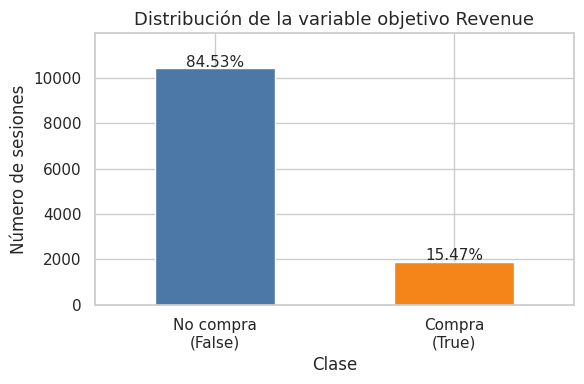

In [ ]:
# ==========================================
# PASO 2B — ANÁLISIS DE LA VARIABLE OBJETIVO (Revenue)
# ==========================================
# Revenue = True  → la sesión terminó en COMPRA (clase positiva, minoritaria)
# Revenue = False → la sesión NO terminó en compra (clase negativa, mayoritaria)
#
# El desbalance de clases es uno de los problemas más comunes en ML aplicado.
# Aquí lo medimos con value_counts() y lo visualizamos con un gráfico de barras.

target_counts = df['Revenue'].value_counts(dropna=False)
target_pct = (target_counts / len(df) * 100).round(2)
balance = pd.DataFrame({'Sesiones': target_counts, 'Porcentaje (%)': target_pct})
balance.index = ['No compra (False)', 'Compra (True)']

print("=== Distribución de la variable objetivo Revenue ===")
display(balance)
print()
print("⚠️  ATENCIÓN: El dataset está desbalanceado.")
print(f"   Solo el {target_pct[True]:.1f}% de las sesiones terminaron en compra.")
print("   Si un modelo predice SIEMPRE 'No compra', obtendría una accuracy de",
      f"{target_pct[False]:.1f}% sin aprender nada útil.")
print("   Por eso usaremos ROC-AUC, F1 y Recall como métricas principales.")

# Gráfico de barras con porcentajes anotados
fig, ax = plt.subplots(figsize=(6, 4))
bars = target_counts.rename(index={False: 'No compra\n(False)', True: 'Compra\n(True)'}).plot(
    kind='bar', color=['#4C78A8', '#F58518'], edgecolor='white', ax=ax
)
for bar, pct in zip(ax.patches, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50, f'{pct}%', ha='center', fontsize=11)
ax.set_title('Distribución de la variable objetivo Revenue', fontsize=13)
ax.set_xlabel('Clase')
ax.set_ylabel('Número de sesiones')
ax.set_ylim(0, target_counts.max() * 1.15)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


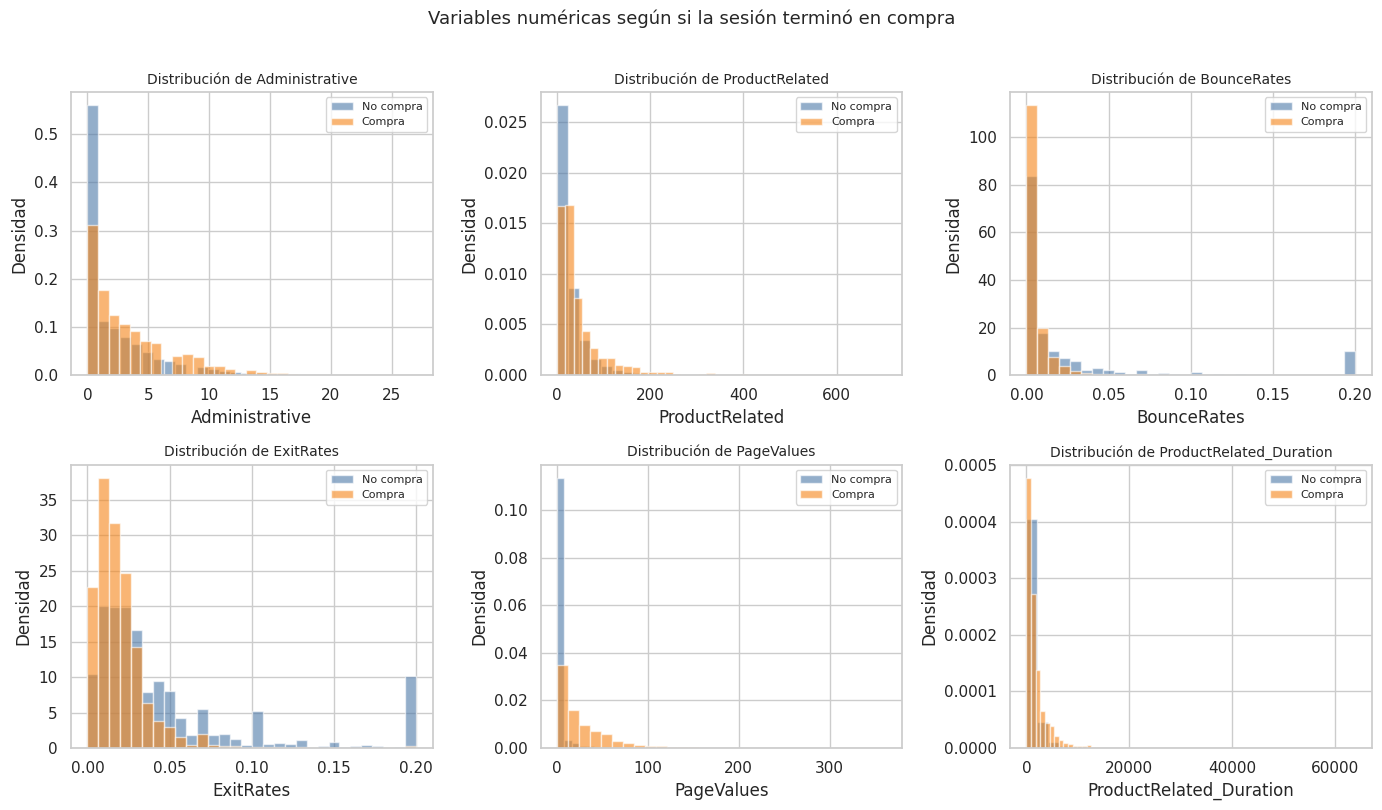

💡 Observa PageValues: las sesiones que terminan en compra tienen
   PageValues mucho más altos. Esto sugiere que es una variable muy predictiva.


In [ ]:
# ==========================================
# PASO 2C — EXPLORACIÓN DE VARIABLES NUMÉRICAS
# ==========================================
# Visualizamos la distribución de las variables numéricas separadas por Revenue.
# Esto nos permite ver qué variables difieren más entre sesiones que compran y las que no.

numeric_cols = ['Administrative', 'ProductRelated', 'BounceRates',
                'ExitRates', 'PageValues', 'ProductRelated_Duration']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for revenue_val, color, label in [(False, '#4C78A8', 'No compra'), (True, '#F58518', 'Compra')]:
        subset = df[df['Revenue'] == revenue_val][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(f'Distribución de {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=8)

plt.suptitle('Variables numéricas según si la sesión terminó en compra', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("💡 Observa PageValues: las sesiones que terminan en compra tienen")
print("   PageValues mucho más altos. Esto sugiere que es una variable muy predictiva.")


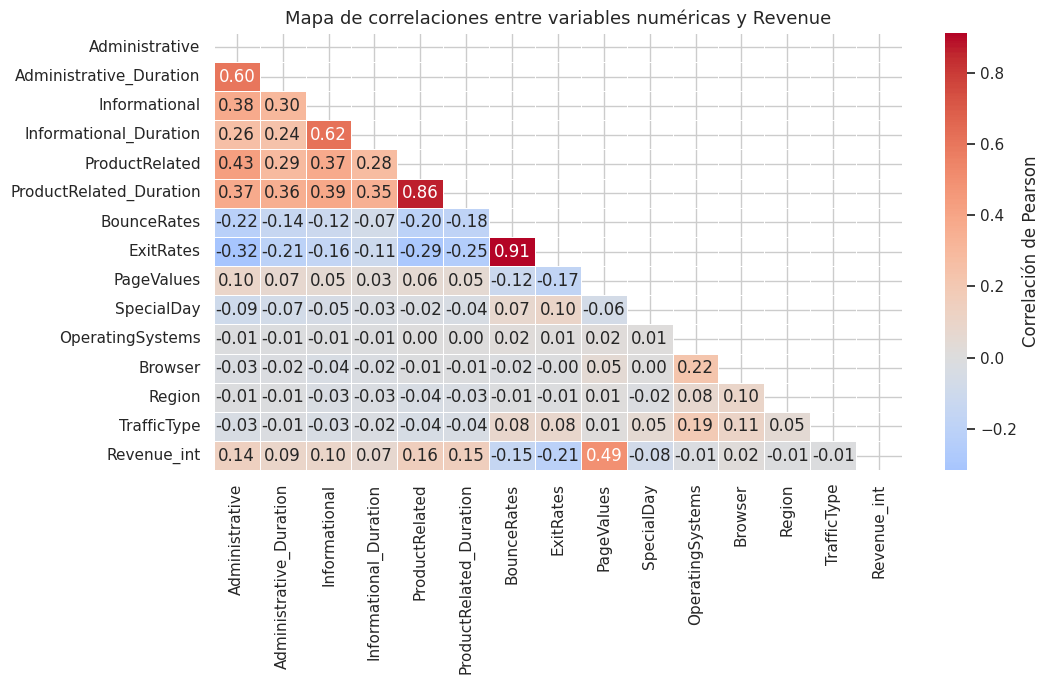

💡 Revisa la última fila (Revenue_int):
   Las variables con mayor correlación absoluta con Revenue son las más prometedoras.


In [ ]:
# ==========================================
# PASO 2D — MAPA DE CORRELACIONES
# ==========================================
# El mapa de calor muestra qué tan relacionadas están las variables numéricas entre sí.
# Correlaciones altas entre predictoras pueden indicar redundancia (multicolinealidad).
# Una correlación alta con Revenue indica potencial predictivo.

df_num = df.select_dtypes(include='number').copy()
df_num['Revenue_int'] = df['Revenue'].astype(int)

corr = df_num.corr()

plt.figure(figsize=(11, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Mostrar solo triángulo inferior
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'label': 'Correlación de Pearson'})
plt.title('Mapa de correlaciones entre variables numéricas y Revenue', fontsize=13)
plt.tight_layout()
plt.show()

print("💡 Revisa la última fila (Revenue_int):")
print("   Las variables con mayor correlación absoluta con Revenue son las más prometedoras.")


### ✏️ Responde las preguntas guía del Paso 2

Antes de continuar al Paso 3, escribe tus respuestas aquí:

1. **¿Cuántas filas y columnas tiene el dataset? ¿Hay valores faltantes?**  
   *...*

2. **¿Qué representa Revenue=True y Revenue=False?**  
   *...*

3. **¿El dataset está balanceado? ¿Por qué accuracy sola sería una métrica engañosa aquí?**  
   *...*

4. **¿Qué variable numérica parece más relacionada con la intención de compra antes de entrenar?**  
   *...*


---
## Paso 3 — Preparación de variables y construcción del Pipeline

### Conceptos clave de este paso

#### ¿Qué es un Pipeline de Scikit-learn?
Un `Pipeline` es un objeto que **encadena pasos de transformación y un modelo** en una sola unidad.  
Cuando llamas a `pipeline.fit(X_train, y_train)`, ejecuta todos los pasos en secuencia:
1. Imputa valores faltantes.
2. Escala variables numéricas.
3. Codifica variables categóricas.
4. Entrena el modelo.

**Ventaja fundamental:** el pipeline garantiza que el preprocesamiento se ajuste **solo sobre datos de entrenamiento** y luego se aplique (sin reajustarse) sobre los datos de prueba. Esto evita la **fuga de datos** (*data leakage*).

#### ¿Qué es la fuga de datos?
Si escalas o imputas usando **toda** la base (incluyendo el conjunto de prueba) antes de dividir, el modelo "ve" información del futuro durante el entrenamiento. El resultado: métricas optimistas que no se repiten en producción.

#### ¿Por qué `stratify=y`?
Con clases desbalanceadas (84/16), una división aleatoria podría poner muy pocos ejemplos de "compra" en el conjunto de prueba por azar. `stratify=y` garantiza que la proporción de clases sea **igual** en train y test.

#### ¿Qué hace `ColumnTransformer`?
Aplica transformaciones distintas según el tipo de columna:
- **Numéricas:** imputación con mediana + estandarización (media=0, std=1).
- **Categóricas:** imputación con moda + One-Hot Encoding.


In [ ]:
# ==========================================
# PASO 3A — SEPARACIÓN DE VARIABLES
# ==========================================
# X contiene las 17 variables predictoras (todo menos Revenue).
# y contiene la variable objetivo Revenue, convertida a entero (0/1).

X = df.drop(columns=['Revenue']).copy()
y = df['Revenue'].astype(int).copy()

# Identificamos automáticamente qué columnas son numéricas y cuáles categóricas.
# Esto hace el código reutilizable con otros datasets.
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

print("Variables numéricas:", numeric_features)
print()
print("Variables categóricas:", categorical_features)
print()
print(f"Total de predictoras: {X.shape[1]} columnas")
print(f"Total de registros: {X.shape[0]:,} sesiones")


Variables numéricas: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Variables categóricas: ['Month', 'VisitorType', 'Weekend']

Total de predictoras: 17 columnas
Total de registros: 12,330 sesiones


In [ ]:
# ==========================================
# PASO 3B — DIVISIÓN ESTRATIFICADA TRAIN/TEST
# ==========================================
# test_size=0.20  → 20% para prueba, 80% para entrenamiento
# random_state=42 → semilla fija para reproducibilidad (todos obtendrán el mismo split)
# stratify=y      → preserva la proporción de clases 84/16 en ambos conjuntos

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]:,} sesiones")
print(f"Tamaño del conjunto de prueba:        {X_test.shape[0]:,} sesiones")
print()
print("Verificación de estratificación (deben ser iguales):")
print(f"  Proporción de compra en train: {y_train.mean():.4f} ({y_train.mean()*100:.1f}%)")
print(f"  Proporción de compra en test:  {y_test.mean():.4f} ({y_test.mean()*100:.1f}%)")
print()
print("✅ La proporción es igual en train y test gracias a stratify=y")


Tamaño del conjunto de entrenamiento: 9,864 sesiones
Tamaño del conjunto de prueba:        2,466 sesiones

Verificación de estratificación (deben ser iguales):
  Proporción de compra en train: 0.1547 (15.5%)
  Proporción de compra en test:  0.1549 (15.5%)

✅ La proporción es igual en train y test gracias a stratify=y


In [ ]:
# ==========================================
# PASO 3C — DEFINICIÓN DEL PREPROCESADOR
# ==========================================
# Construimos el preprocesador como un ColumnTransformer.
# Este objeto aplica transformaciones DISTINTAS según el tipo de variable.
#
# Para variables NUMÉRICAS:
#   1. SimpleImputer(median): rellena valores faltantes con la mediana de la columna.
#      Usamos mediana (no media) porque es robusta ante valores extremos (outliers).
#   2. StandardScaler: resta la media y divide por la desviación estándar.
#      Resultado: cada variable tiene media ≈ 0 y desviación estándar ≈ 1.
#      Esto es importante para algoritmos sensibles a la escala (aunque no para árboles).
#
# Para variables CATEGÓRICAS:
#   1. SimpleImputer(most_frequent): rellena faltantes con el valor más común.
#   2. OneHotEncoder(handle_unknown='ignore'): convierte cada categoría en una columna
#      binaria. handle_unknown='ignore' evita errores si aparece una categoría nueva
#      en producción que no existía en el entrenamiento.

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'  # Descartar cualquier columna no listada explícitamente
)

print("✅ Preprocesador definido. Pasos:")
print("   Numéricas  →  Imputación (mediana) → Estandarización (StandardScaler)")
print("   Categóricas →  Imputación (moda)   → One-Hot Encoding")
print()
print("⚠️  El preprocesador aún NO está ajustado (fit).")
print("   Se ajustará SOLO sobre X_train cuando construyamos el Pipeline completo.")


✅ Preprocesador definido. Pasos:
   Numéricas  →  Imputación (mediana) → Estandarización (StandardScaler)
   Categóricas →  Imputación (moda)   → One-Hot Encoding

⚠️  El preprocesador aún NO está ajustado (fit).
   Se ajustará SOLO sobre X_train cuando construyamos el Pipeline completo.


### ✏️ Responde las preguntas guía del Paso 3

1. **¿Qué columnas son numéricas y cuáles categóricas en este dataset?**  
   *...*

2. **¿Por qué se usa `stratify=y` en la partición train/test?**  
   *...*

3. **¿Qué problema evita encapsular el preprocesamiento dentro de un Pipeline?**  
   *...*

4. **¿Por qué usamos mediana (y no media) para imputar variables numéricas?**  
   *...*


---
## Paso 4 — Taxonomía y selección de modelos

### ¿Cómo elegir un algoritmo?
No existe "el mejor algoritmo universal" (teorema No Free Lunch).  
La elección depende de:

| Criterio | Decision Tree | Random Forest | XGBoost |
|----------|---------------|---------------|---------|
| **Interpretabilidad** | ⭐⭐⭐ Alta | ⭐⭐ Media | ⭐ Baja |
| **Desempeño** | ⭐ Bajo | ⭐⭐⭐ Alto | ⭐⭐⭐ Alto |
| **Velocidad de entrenamiento** | ⭐⭐⭐ Muy rápido | ⭐⭐ Medio | ⭐⭐ Medio |
| **Requiere ajuste fino** | No | Poco | Sí |
| **Manejo de desbalance** | class_weight | class_weight | scale_pos_weight |

### ¿Qué es un árbol de decisión?
Un árbol de decisión es una serie de preguntas binarias (`¿PageValues > 5?`) organizadas en una estructura de árbol. Es el modelo más interpretable: puedes seguir cada rama y entender exactamente por qué predijo lo que predijo.

**Problema:** tiende al sobreajuste si crece demasiado. Por eso limitamos `max_depth`.

### ¿Qué es Random Forest?
Un Random Forest entrena **muchos árboles** sobre muestras aleatorias de los datos y variables, y luego promedia sus predicciones. Al promediar, se reduce la varianza y el sobreajuste. Generalmente supera al árbol individual en desempeño.

### ¿Qué es XGBoost?
XGBoost usa **Gradient Boosting**: construye árboles en secuencia, donde cada árbol nuevo aprende a corregir los errores del anterior. Es el algoritmo dominante en competencias de datos tabulares. Requiere más ajuste de hiperparámetros.

### ¿Por qué `class_weight='balanced'`?
Con clases desbalanceadas, los algoritmos tienden a favorecer a la clase mayoritaria.  
`class_weight='balanced'` ajusta automáticamente los pesos para que el modelo preste más atención a la clase minoritaria (compra).


In [ ]:
# ==========================================
# PASO 4A — DEFINICIÓN DE MODELOS CANDIDATOS
# ==========================================
# Definimos los tres modelos con hiperparámetros iniciales razonables.
# Usamos class_weight='balanced' para compensar el desbalance de clases.
# Todos tendrán random_state=42 para reproducibilidad.

modelos = {
    # ── Decision Tree ──────────────────────────────────────────────────────
    # max_depth=5: limita la profundidad máxima para evitar sobreajuste.
    #              Un árbol sin límite memoriza el conjunto de entrenamiento.
    # min_samples_leaf=30: cada hoja debe tener al menos 30 muestras.
    #                      Evita ramas que aplican a muy pocos casos.
    # class_weight='balanced': penaliza más los errores en la clase minoritaria.
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=30,
        class_weight='balanced',
        random_state=42
    ),

    # ── Random Forest ──────────────────────────────────────────────────────
    # n_estimators=250: número de árboles en el bosque.
    #                   Más árboles = más estable, pero más lento de entrenar.
    # max_depth=None: los árboles individuales pueden crecer libremente
    #                 (la diversidad entre árboles controla el sobreajuste).
    # min_samples_leaf=5: cada hoja necesita al menos 5 muestras.
    # n_jobs=-1: usa todos los núcleos del procesador en paralelo.
    'Random Forest': RandomForestClassifier(
        n_estimators=250,
        max_depth=None,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    # ── XGBoost ────────────────────────────────────────────────────────────
    # n_estimators=250: número de árboles en la secuencia de boosting.
    # max_depth=4: cada árbol individual es pequeño (árbol débil o "weak learner").
    # learning_rate=0.05: cuánto "aprende" cada árbol nuevo. Valores pequeños
    #                     requieren más árboles pero generalizan mejor.
    # subsample=0.9: cada árbol usa el 90% de las filas seleccionadas aleatoriamente.
    # colsample_bytree=0.9: cada árbol usa el 90% de las columnas.
    # eval_metric='logloss': métrica interna para monitorear el entrenamiento.
    'XGBoost': XGBClassifier(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
}

# Construimos un Pipeline completo para cada modelo.
# Cada pipeline incluye: preprocesador → modelo.
# Esto garantiza que el preprocesamiento esté DENTRO del pipeline
# y se ajuste correctamente durante cross-validation.
pipelines = {
    nombre: Pipeline(steps=[
        ('preprocess', preprocessor),  # Paso 1: transformar los datos
        ('model', modelo)              # Paso 2: entrenar el modelo
    ])
    for nombre, modelo in modelos.items()
}

print("✅ Modelos candidatos definidos:")
for nombre, p in pipelines.items():
    print(f"   • {nombre}")
print()
print("Cada modelo está envuelto en un Pipeline con preprocesamiento.")
print("Esto garantiza que NO haya fuga de datos durante la validación cruzada.")


✅ Modelos candidatos definidos:
   • Decision Tree
   • Random Forest
   • XGBoost

Cada modelo está envuelto en un Pipeline con preprocesamiento.
Esto garantiza que NO haya fuga de datos durante la validación cruzada.


### ✏️ Ficha de decisión del modelo

Completa esta ficha **antes de ver los resultados** del Paso 5:

- **Tipo de problema:** Clasificación binaria (¿Revenue = True o False?)
- **Variable objetivo:** `Revenue`
- **Modelos candidatos:** Decision Tree, Random Forest, XGBoost
- **Criterios de comparación:** ROC-AUC, F1, Recall de la clase compra, interpretabilidad

> **Pregunta:** ¿Cuál modelo esperas que funcione mejor y por qué?  
> *Escribe tu hipótesis aquí antes de ejecutar el Paso 5...*


---
## Paso 5 — Entrenamiento y evaluación comparativa

### ¿Por qué no basta con accuracy?
Imagina un dataset donde el 95% de los casos son negativos. Un modelo que siempre predice "negativo" obtiene 95% de accuracy sin aprender nada.

Las métricas que usaremos:

| Métrica | Fórmula conceptual | Cuándo priorizarla |
|---------|-------------------|--------------------|
| **Accuracy** | Correctos / Total | Solo si las clases están balanceadas |
| **Precision** | VP / (VP + FP) | Cuando el costo de los falsos positivos es alto |
| **Recall** | VP / (VP + FN) | Cuando el costo de NO detectar un positivo es alto |
| **F1** | 2 × (P × R) / (P + R) | Cuando buscamos equilibrio entre Precision y Recall |
| **ROC-AUC** | Área bajo la curva ROC | Métrica global de discriminación, independiente del umbral |

*VP = Verdadero Positivo, FP = Falso Positivo, FN = Falso Negativo*

### ¿Qué es la curva ROC?
La curva ROC grafica la **Tasa de Verdaderos Positivos** (Recall) vs la **Tasa de Falsos Positivos** para todos los umbrales de decisión posibles.  
Un modelo perfecto tiene ROC-AUC = 1.0; un modelo aleatorio tiene ROC-AUC = 0.5.


In [ ]:
# ==========================================
# PASO 5A — FUNCIÓN DE EVALUACIÓN
# ==========================================
# Encapsulamos la evaluación en una función para no repetir código.
# La función recibe el pipeline, lo entrena, predice y devuelve un diccionario
# con todas las métricas relevantes.

def evaluar_modelo(nombre, pipeline, X_train, X_test, y_train, y_test):
    """
    Entrena el pipeline y calcula métricas de evaluación sobre el conjunto de prueba.

    Parámetros:
    -----------
    nombre      : str        — Nombre del modelo para la tabla de resultados
    pipeline    : Pipeline   — Pipeline completo (preprocesamiento + modelo)
    X_train     : DataFrame  — Variables predictoras de entrenamiento
    X_test      : DataFrame  — Variables predictoras de prueba
    y_train     : Series     — Variable objetivo de entrenamiento
    y_test      : Series     — Variable objetivo de prueba

    Retorna:
    --------
    dict con nombre del modelo y métricas: accuracy, precision, recall, f1, roc_auc
    """
    # fit() ejecuta: preprocesar datos → entrenar modelo
    pipeline.fit(X_train, y_train)

    # predict() aplica el umbral 0.5: si P(compra) >= 0.5 → predice compra
    y_pred = pipeline.predict(X_test)

    # predict_proba() devuelve la probabilidad para cada clase: [P(no compra), P(compra)]
    # Tomamos la columna 1 que corresponde a P(compra)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    return {
        'Modelo': nombre,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_proba)
    }

print("✅ Función de evaluación definida.")


✅ Función de evaluación definida.


In [ ]:
# ==========================================
# PASO 5B — ENTRENAMIENTO Y TABLA COMPARATIVA
# ==========================================
# Entrenamos y evaluamos cada modelo con la función que definimos.
# Este paso puede tardar 1-2 minutos en Colab.

print("Entrenando modelos... (puede tardar 1-2 minutos)")
print("-" * 50)

resultados = []
for nombre, pipeline in pipelines.items():
    print(f"  ⏳ Entrenando: {nombre}...")
    resultado = evaluar_modelo(nombre, pipeline, X_train, X_test, y_train, y_test)
    resultados.append(resultado)
    print(f"     ROC-AUC: {resultado['ROC-AUC']:.3f}  |  F1: {resultado['F1']:.3f}  |  Recall: {resultado['Recall']:.3f}")

print("-" * 50)
print()

# Creamos un DataFrame con todos los resultados y lo ordenamos por ROC-AUC
resultados_df = pd.DataFrame(resultados).set_index('Modelo').sort_values('ROC-AUC', ascending=False)

print("=== Tabla comparativa de modelos ===")
display(resultados_df.style
    .format('{:.3f}')
    .background_gradient(cmap='RdYlGn', subset=['ROC-AUC', 'F1', 'Recall'])
    .set_caption('Métricas sobre el conjunto de prueba (20% de los datos)')
)

mejor_nombre = resultados_df.index[0]
mejor_pipeline = pipelines[mejor_nombre]
print(f"\n🏆 Mejor modelo preliminar (por ROC-AUC): {mejor_nombre}")


Entrenando modelos... (puede tardar 1-2 minutos)
--------------------------------------------------
  ⏳ Entrenando: Decision Tree...
     ROC-AUC: 0.915  |  F1: 0.625  |  Recall: 0.827
  ⏳ Entrenando: Random Forest...
     ROC-AUC: 0.925  |  F1: 0.658  |  Recall: 0.733
  ⏳ Entrenando: XGBoost...
     ROC-AUC: 0.929  |  F1: 0.645  |  Recall: 0.584
--------------------------------------------------

=== Tabla comparativa de modelos ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
XGBoost,0.901,0.722,0.584,0.645,0.929
Random Forest,0.882,0.597,0.733,0.658,0.925
Decision Tree,0.846,0.502,0.827,0.625,0.915



🏆 Mejor modelo preliminar (por ROC-AUC): XGBoost


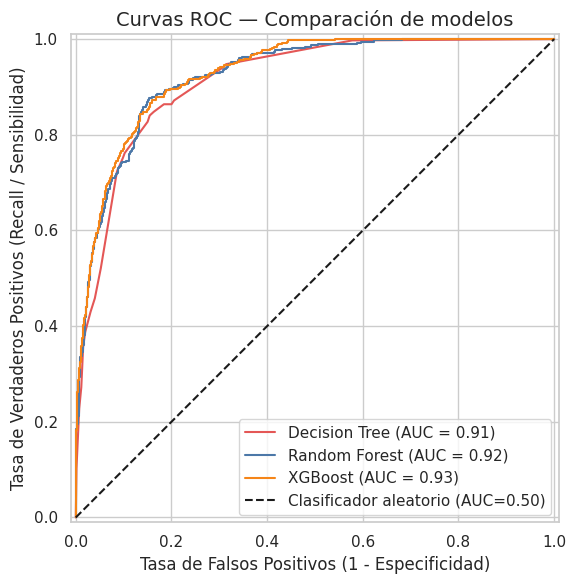

💡 La curva ROC muestra qué tan bien cada modelo distingue compradores
   de no compradores a TODOS los umbrales posibles.


In [ ]:
# ==========================================
# PASO 5C — CURVAS ROC DE LOS TRES MODELOS
# ==========================================
# La curva ROC nos permite comparar visualmente los modelos
# sin depender de un umbral fijo de clasificación.
# El área bajo la curva (AUC) resume el desempeño en un solo número.
#
# Interpretación:
#   - Curva más cercana a la esquina superior izquierda = mejor modelo
#   - Línea diagonal = modelo aleatorio (AUC = 0.5)

fig, ax = plt.subplots(figsize=(8, 6))

colores = {'Decision Tree': '#E45756', 'Random Forest': '#4C78A8', 'XGBoost': '#F58518'}
for nombre, pipeline in pipelines.items():
    RocCurveDisplay.from_estimator(
        pipeline, X_test, y_test, ax=ax, name=nombre,
        color=colores.get(nombre)
    )

ax.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio (AUC=0.50)')
ax.set_title('Curvas ROC — Comparación de modelos', fontsize=14)
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall / Sensibilidad)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("💡 La curva ROC muestra qué tan bien cada modelo distingue compradores")
print("   de no compradores a TODOS los umbrales posibles.")


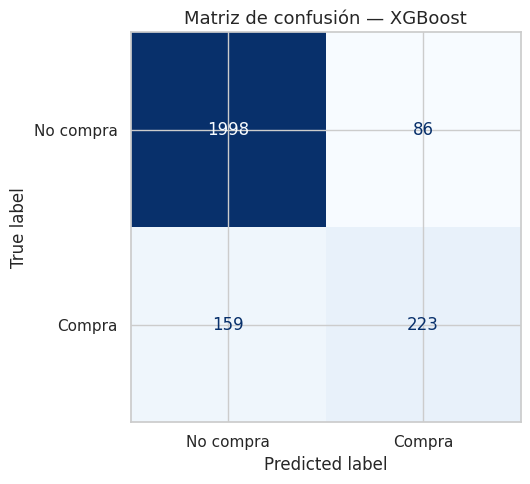


=== Reporte de clasificación detallado — XGBoost ===
              precision    recall  f1-score   support

   No compra       0.93      0.96      0.94      2084
      Compra       0.72      0.58      0.65       382

    accuracy                           0.90      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.90      0.90      2466


💡 Interpretación:
   • Precision de 'Compra': de cada sesión predicha como compra, ¿qué % realmente compró?
   • Recall de 'Compra': de todos los compradores reales, ¿qué % detectó el modelo?
   • En e-commerce, el Recall suele ser más importante: no queremos perder compradores.


In [ ]:
# ==========================================
# PASO 5D — MATRIZ DE CONFUSIÓN DEL MEJOR MODELO
# ==========================================
# La matriz de confusión desglosa las predicciones en 4 categorías:
#
#                    Predicho: No compra  |  Predicho: Compra
#  Real: No compra       TN (Verdadero Negativo)  |  FP (Falso Positivo)
#  Real: Compra          FN (Falso Negativo)       |  VP (Verdadero Positivo)
#
# Para la tienda en línea:
#   FN = Comprador que NO identificamos (perdemos la oportunidad de convertirlo)
#   FP = No comprador al que le mostramos oferta (costo de campaña desperdiciada)

y_pred_best = mejor_pipeline.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['No compra', 'Compra']).plot(
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title(f'Matriz de confusión — {mejor_nombre}', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n=== Reporte de clasificación detallado — {mejor_nombre} ===")
print(classification_report(y_test, y_pred_best, target_names=['No compra', 'Compra']))
print()
print("💡 Interpretación:")
print("   • Precision de 'Compra': de cada sesión predicha como compra, ¿qué % realmente compró?")
print("   • Recall de 'Compra': de todos los compradores reales, ¿qué % detectó el modelo?")
print("   • En e-commerce, el Recall suele ser más importante: no queremos perder compradores.")


### ✏️ Responde las preguntas guía del Paso 5

1. **¿Qué modelo obtuvo el mejor ROC-AUC? ¿Coincidió con tu hipótesis inicial?**  
   *...*

2. **Si la tienda quiere detectar la mayor cantidad posible de compradores potenciales, ¿qué métrica priorizarías: Precision o Recall? ¿Por qué?**  
   *...*

3. **¿Qué errores son más costosos para la tienda: Falsos Positivos (FP) o Falsos Negativos (FN)? Justifica desde el punto de vista del negocio.**  
   *...*

4. **¿Podría un modelo con menor Accuracy tener mejor F1 que otro? ¿En qué situación?**  
   *...*


---
## Paso 6 — Interpretabilidad: árboles e importancia de variables

### ¿Por qué importa la interpretabilidad?
Un modelo opaco puede tener excelente desempeño pero ser inutilizable en la práctica porque:
- Los tomadores de decisiones necesitan entender **por qué** el modelo predice algo.
- Las regulaciones (GDPR en Europa, por ejemplo) pueden requerir explicaciones de las decisiones automatizadas.
- La interpretabilidad ayuda a detectar **sesgos ocultos** en el modelo.

### Árbol de decisión interpretable
Entrenaremos un árbol MUY PEQUEÑO (máximo 3 niveles) que podemos leer completamente.  
Aunque su desempeño es menor que Random Forest o XGBoost, nos enseña qué preguntas hace el modelo.

### Importancia de variables en Random Forest
Random Forest calcula la importancia de cada variable como el **promedio de cuánto cada árbol reduce la impureza** cuando usa esa variable para dividir. Una variable con importancia alta es más usada y más útil para predecir.


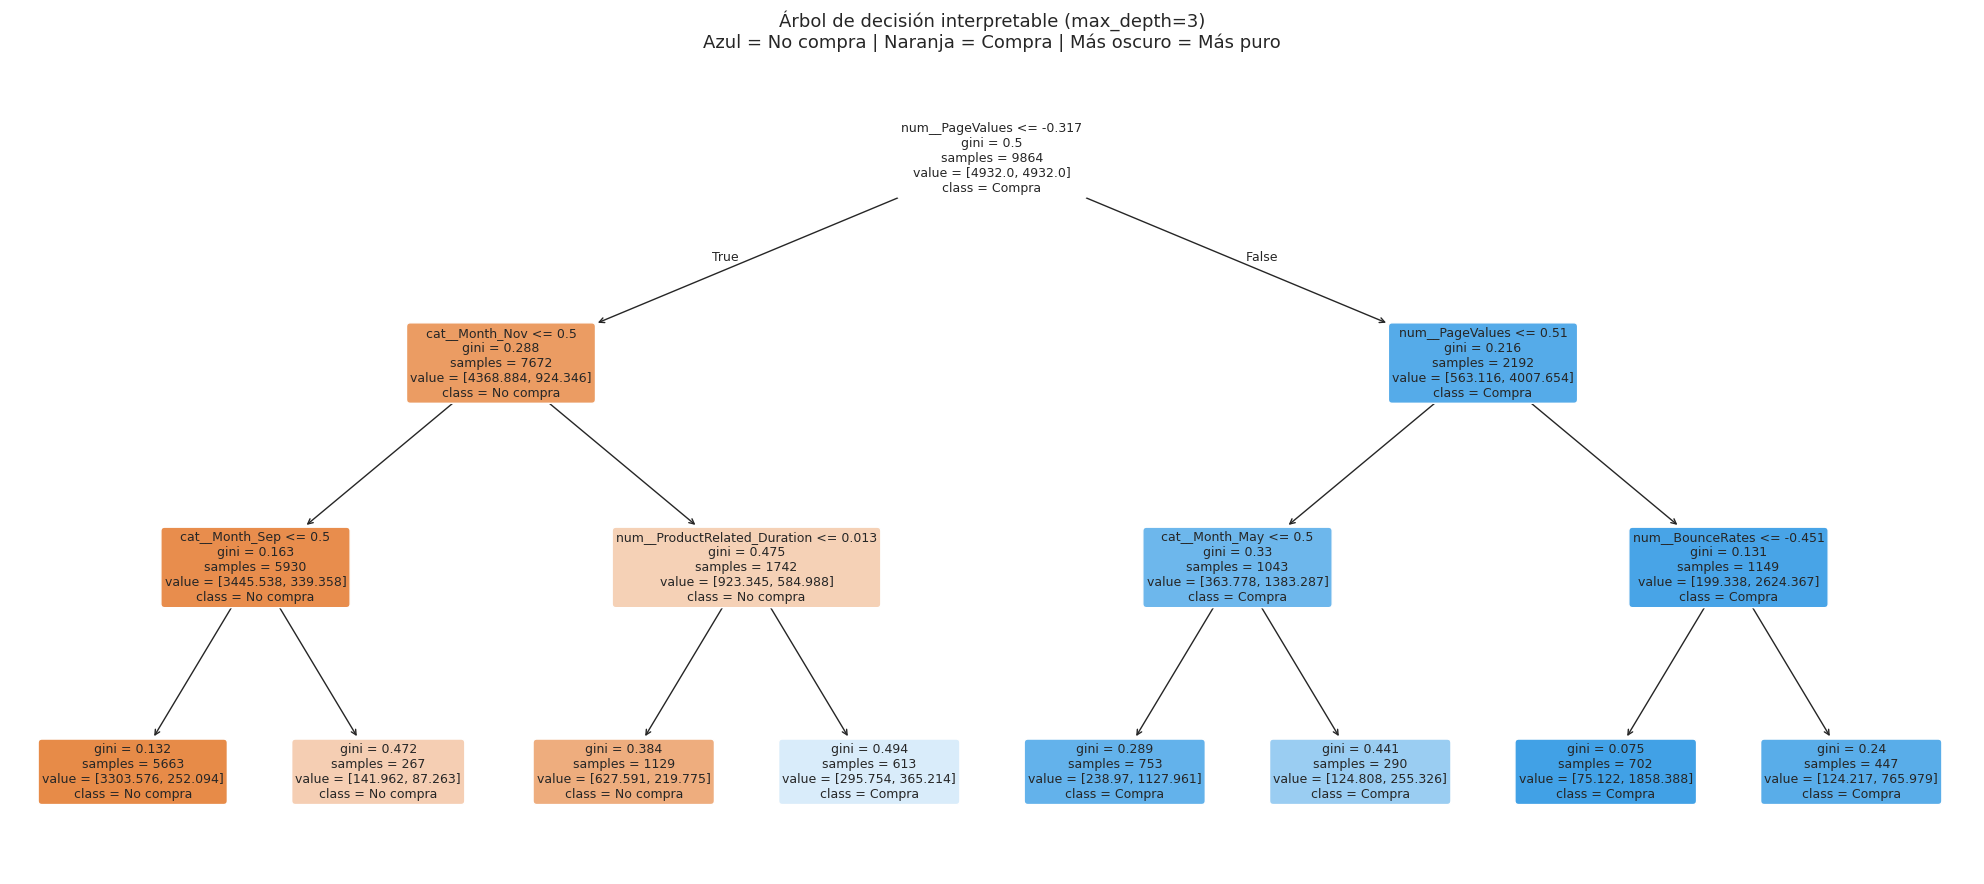

💡 Cómo leer el árbol:
   • Cada nodo muestra: variable de corte, umbral, índice Gini, muestras, distribución de clases
   • Gini=0: nodo puro (todas las muestras son de la misma clase)
   • Gini=0.5: nodo perfectamente mezclado (50/50)
   • La variable en la raíz (primera pregunta) es la más discriminante


In [ ]:
# ==========================================
# PASO 6A — ÁRBOL DE DECISIÓN INTERPRETABLE (PROFUNDIDAD 3)
# ==========================================
# Entrenamos un árbol muy pequeño (max_depth=3) que podamos leer completamente.
# Aunque su desempeño es menor, podemos seguir cada rama y entender la lógica.

arbol_interpretable = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=3,           # Máximo 3 niveles de preguntas
        min_samples_leaf=50,   # Cada hoja necesita al menos 50 muestras
        class_weight='balanced',
        random_state=42
    ))
])
arbol_interpretable.fit(X_train, y_train)

# Obtenemos los nombres de las variables DESPUÉS del preprocesamiento
# (el OneHotEncoder genera nuevas columnas)
feature_names = arbol_interpretable.named_steps['preprocess'].get_feature_names_out()

plt.figure(figsize=(20, 9))
plot_tree(
    arbol_interpretable.named_steps['model'],
    feature_names=feature_names,
    class_names=['No compra', 'Compra'],
    filled=True,         # Colorea los nodos según la clase dominante
    rounded=True,        # Bordes redondeados para mejor legibilidad
    fontsize=9,
    impurity=True,       # Muestra el índice Gini en cada nodo
    proportion=False     # Muestra conteos absolutos, no proporciones
)
plt.title('Árbol de decisión interpretable (max_depth=3)\n'
          'Azul = No compra | Naranja = Compra | Más oscuro = Más puro', fontsize=13)
plt.tight_layout()
plt.show()

print("💡 Cómo leer el árbol:")
print("   • Cada nodo muestra: variable de corte, umbral, índice Gini, muestras, distribución de clases")
print("   • Gini=0: nodo puro (todas las muestras son de la misma clase)")
print("   • Gini=0.5: nodo perfectamente mezclado (50/50)")
print("   • La variable en la raíz (primera pregunta) es la más discriminante")


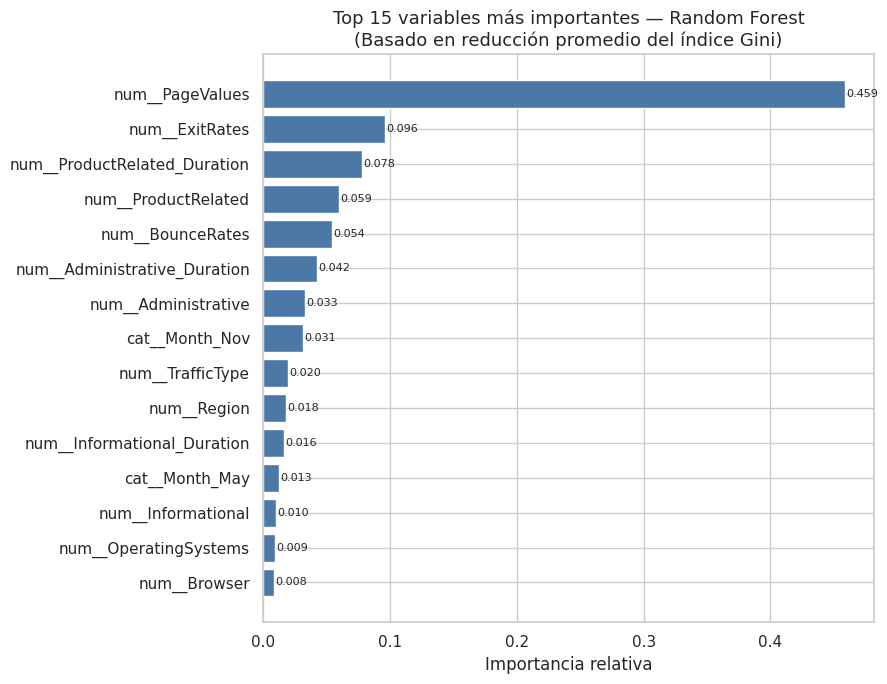

=== Top 15 variables más importantes ===


,Variable,Importancia
8,num__PageValues,0.4586
7,num__ExitRates,0.0958
5,num__ProductRelated_Duration,0.0780
4,num__ProductRelated,0.0594
6,num__BounceRates,0.0545
1,num__Administrative_Duration,0.0424
0,num__Administrative,0.0326
21,cat__Month_Nov,0.0312
13,num__TrafficType,0.0196
12,num__Region,0.0176


In [ ]:
# ==========================================
# PASO 6B — IMPORTANCIA DE VARIABLES (RANDOM FOREST)
# ==========================================
# La importancia de cada variable = promedio de la reducción de impureza Gini
# que aporta esa variable en todos los árboles del bosque.
# Variable con mayor importancia → más útil para predecir Revenue.

# Usamos el pipeline de Random Forest que ya fue entrenado en el Paso 5
rf_pipeline = pipelines['Random Forest']

# Obtenemos los nombres de variables después del preprocesamiento
rf_features = rf_pipeline.named_steps['preprocess'].get_feature_names_out()

# Obtenemos las importancias del modelo Random Forest
rf_importances = rf_pipeline.named_steps['model'].feature_importances_

# Creamos un DataFrame y ordenamos de mayor a menor importancia
imp_df = pd.DataFrame({
    'Variable': rf_features,
    'Importancia': rf_importances
}).sort_values('Importancia', ascending=False).head(15)

# Gráfico de barras horizontales (más legible que verticales con nombres largos)
fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(imp_df['Variable'][::-1], imp_df['Importancia'][::-1], color='#4C78A8', edgecolor='white')
ax.set_title('Top 15 variables más importantes — Random Forest\n'
             '(Basado en reducción promedio del índice Gini)', fontsize=13)
ax.set_xlabel('Importancia relativa')
ax.set_ylabel('')

# Anotamos el valor en cada barra
for bar, val in zip(bars, imp_df['Importancia'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("=== Top 15 variables más importantes ===")
display(imp_df.style.bar(subset=['Importancia'], color='#4C78A8').format({'Importancia': '{:.4f}'}))


In [ ]:
# ==========================================
# PASO 6C — COMPARACIÓN DE IMPORTANCIAS ENTRE MODELOS
# ==========================================
# XGBoost también tiene su propia medida de importancia de variables.
# Comparamos las top variables según ambos modelos para ver si coinciden.

xgb_pipeline = pipelines['XGBoost']
xgb_features = xgb_pipeline.named_steps['preprocess'].get_feature_names_out()
xgb_importances = xgb_pipeline.named_steps['model'].feature_importances_

xgb_imp_df = pd.DataFrame({
    'Variable': xgb_features,
    'Importancia XGBoost': xgb_importances
}).sort_values('Importancia XGBoost', ascending=False).head(10).reset_index(drop=True)

rf_imp_top = imp_df[['Variable', 'Importancia']].head(10).reset_index(drop=True)
rf_imp_top.columns = ['Variable', 'Importancia RF']

print("=== Top 10 variables según Random Forest ===")
display(rf_imp_top)
print()
print("=== Top 10 variables según XGBoost ===")
display(xgb_imp_df)
print()
print("💡 Si ambos modelos coinciden en las variables más importantes,")
print("   hay evidencia más sólida de que esas variables realmente predicen la compra.")


=== Top 10 variables según Random Forest ===


,Variable,Importancia RF
0,num__PageValues,0.458625
1,num__ExitRates,0.095777
2,num__ProductRelated_Duration,0.078008
3,num__ProductRelated,0.059391
4,num__BounceRates,0.054478
5,num__Administrative_Duration,0.042441
6,num__Administrative,0.032614
7,cat__Month_Nov,0.031169
8,num__TrafficType,0.019641
9,num__Region,0.017619



=== Top 10 variables según XGBoost ===


,Variable,Importancia XGBoost
0,num__PageValues,0.372999
1,cat__Month_Nov,0.080040
2,cat__Month_May,0.050813
3,cat__Month_Mar,0.046276
4,cat__Month_Sep,0.039195
5,cat__VisitorType_Returning_Visitor,0.035668
6,num__ExitRates,0.032403
7,num__Administrative,0.028340
8,num__BounceRates,0.028300
9,num__ProductRelated_Duration,0.024345



💡 Si ambos modelos coinciden en las variables más importantes,
   hay evidencia más sólida de que esas variables realmente predicen la compra.


### ✏️ Responde las preguntas guía del Paso 6

1. **¿Qué variable aparece en la raíz del árbol de decisión? ¿Por qué crees que es la más discriminante?**  
   *...*

2. **¿Las variables más importantes del modelo coinciden con las que tenías mayor correlación con Revenue en el Paso 2?**  
   *...*

3. **¿Coinciden las top variables entre Random Forest y XGBoost? ¿Qué implicación tiene eso?**  
   *...*

4. **¿Qué ventaja pedagógica tiene mostrar un árbol de decisión pequeño ANTES de modelos más complejos?**  
   *...*


---
## Paso 7 — Validación rigurosa: Cross-Validation y ajuste de hiperparámetros

### ¿Por qué no basta con un solo train/test split?
Un split único puede ser "afortunado" o "desafortunado" dependiendo de qué datos quedaron en cada conjunto.  
**Validación cruzada (Cross-Validation)** entrena y evalúa el modelo múltiples veces sobre diferentes particiones, dando una estimación más confiable del desempeño real.

### ¿Qué es K-Fold Estratificado?
`StratifiedKFold(n_splits=5)` divide los datos en 5 partes (*folds*) preservando la proporción de clases.  
En cada iteración, 4 partes se usan para entrenar y 1 para validar. Se obtienen 5 puntuaciones y se reporta la media ± desviación estándar.

### ¿Qué es `RandomizedSearchCV`?
En lugar de probar todas las combinaciones posibles de hiperparámetros (Grid Search), `RandomizedSearchCV` prueba un número aleatorio de combinaciones. Es más eficiente y suele encontrar configuraciones muy buenas con menos tiempo de cómputo.

**Importante:** Usamos Cross-Validation DENTRO del pipeline para que cada fold ajuste su propio preprocesamiento. Esto garantiza una evaluación sin fuga de datos.


In [ ]:
# ==========================================
# PASO 7A — VALIDACIÓN CRUZADA (5-FOLD ESTRATIFICADO)
# ==========================================
# Aplicamos validación cruzada a los tres modelos usando el dataset COMPLETO.
# El pipeline garantiza que cada fold ajuste su propio preprocesamiento.
#
# NOTA: Esto puede tardar 3-5 minutos en Colab porque entrena
# 3 modelos × 5 folds = 15 entrenamientos completos.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Ejecutando validación cruzada (5 folds)... puede tardar unos minutos.")
print("-" * 60)

cv_rows = []
for nombre, pipeline in pipelines.items():
    print(f"  ⏳ Validando: {nombre}...")
    # cross_val_score entrena y evalúa el pipeline en cada fold
    # n_jobs=-1 paralleliza los 5 folds
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_rows.append({
        'Modelo': nombre,
        'ROC-AUC CV (media)': scores.mean(),
        'ROC-AUC CV (std)':   scores.std(),
        'ROC-AUC CV (min)':   scores.min(),
        'ROC-AUC CV (max)':   scores.max(),
        'Scores individuales': list(scores.round(3))
    })
    print(f"     Media: {scores.mean():.4f} ± {scores.std():.4f}  |  Scores: {list(scores.round(3))}")

print("-" * 60)
cv_df = pd.DataFrame(cv_rows).set_index('Modelo')

print("\n=== Resultados de validación cruzada ===")
display(cv_df[['ROC-AUC CV (media)', 'ROC-AUC CV (std)', 'ROC-AUC CV (min)', 'ROC-AUC CV (max)']].style
    .format('{:.4f}')
    .background_gradient(cmap='RdYlGn', subset=['ROC-AUC CV (media)'])
)
print()
print("💡 La desviación estándar (std) indica estabilidad:")
print("   Un std bajo significa que el modelo se comporta consistentemente en diferentes particiones.")
print("   Un std alto indica que el modelo es sensible a qué datos se usan para entrenar.")


Ejecutando validación cruzada (5 folds)... puede tardar unos minutos.
------------------------------------------------------------
  ⏳ Validando: Decision Tree...
     Media: 0.9217 ± 0.0074  |  Scores: [np.float64(0.932), np.float64(0.909), np.float64(0.924), np.float64(0.924), np.float64(0.92)]
  ⏳ Validando: Random Forest...
     Media: 0.9319 ± 0.0038  |  Scores: [np.float64(0.939), np.float64(0.929), np.float64(0.931), np.float64(0.932), np.float64(0.928)]
  ⏳ Validando: XGBoost...
     Media: 0.9324 ± 0.0047  |  Scores: [np.float64(0.94), np.float64(0.926), np.float64(0.934), np.float64(0.933), np.float64(0.929)]
------------------------------------------------------------

=== Resultados de validación cruzada ===


,ROC-AUC CV (media),ROC-AUC CV (std),ROC-AUC CV (min),ROC-AUC CV (max)
Modelo,,,,
Decision Tree,0.9217,0.0074,0.9090,0.9319
Random Forest,0.9319,0.0038,0.9278,0.9389
XGBoost,0.9324,0.0047,0.9258,0.9399



💡 La desviación estándar (std) indica estabilidad:
   Un std bajo significa que el modelo se comporta consistentemente en diferentes particiones.
   Un std alto indica que el modelo es sensible a qué datos se usan para entrenar.


In [ ]:
# ==========================================
# PASO 7B — BÚSQUEDA DE HIPERPARÁMETROS CON RandomizedSearchCV
# ==========================================
# Ajustamos el mejor modelo (Random Forest) buscando la combinación de
# hiperparámetros que maximice el ROC-AUC en validación cruzada.
#
# El espacio de búsqueda define rangos para cada hiperparámetro:
#   n_estimators:    número de árboles en el bosque
#   max_depth:       profundidad máxima de cada árbol
#   min_samples_leaf: mínimo de muestras en cada hoja
#   max_features:    número de variables a considerar en cada división
#
# n_iter=12: probamos 12 combinaciones aleatorias del espacio de hiperparámetros.
# Con un Grid Search completo serían 4×4×3×2 = 96 combinaciones.
# RandomizedSearch encuentra resultados similares en mucho menos tiempo.

rf_search_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

param_dist = {
    'model__n_estimators':    [150, 250, 400],       # Árboles en el bosque
    'model__max_depth':       [None, 6, 10, 14],      # Profundidad máxima
    'model__min_samples_leaf': [2, 5, 10],            # Mínimo de muestras por hoja
    'model__max_features':    ['sqrt', 'log2']        # Nº de variables por split
}

print("Buscando mejores hiperparámetros (puede tardar 3-5 minutos)...")
print(f"Espacio de búsqueda: {3*4*3*2} combinaciones posibles")
print(f"Combinaciones que probaremos: 12 (RandomizedSearch)")
print("-" * 50)

search = RandomizedSearchCV(
    rf_search_pipeline,
    param_distributions=param_dist,
    n_iter=12,              # Número de combinaciones a probar
    scoring='roc_auc',      # Métrica a maximizar
    cv=cv,                  # Mismo K-Fold estratificado de 5 folds
    random_state=42,
    n_jobs=-1,              # Paralelizar en todos los núcleos
    verbose=1               # Mostrar progreso
)

search.fit(X_train, y_train)

print("\n✅ Búsqueda completada.")
print("\nMejores hiperparámetros encontrados:")
for param, valor in search.best_params_.items():
    param_limpio = param.replace('model__', '')
    print(f"   • {param_limpio}: {valor}")
print(f"\nMejor ROC-AUC en validación cruzada: {search.best_score_:.4f}")

# Evaluamos el modelo optimizado sobre el conjunto de prueba
modelo_final = search.best_estimator_
final_proba  = modelo_final.predict_proba(X_test)[:, 1]
final_pred   = modelo_final.predict(X_test)

print(f"\nDesempeño del modelo optimizado sobre el conjunto de PRUEBA:")
print(f"   ROC-AUC test: {roc_auc_score(y_test, final_proba):.4f}")
print(f"   F1 test:      {f1_score(y_test, final_pred):.4f}")
print(f"   Recall test:  {recall_score(y_test, final_pred):.4f}")


Buscando mejores hiperparámetros (puede tardar 3-5 minutos)...
Espacio de búsqueda: 72 combinaciones posibles
Combinaciones que probaremos: 12 (RandomizedSearch)
--------------------------------------------------
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Búsqueda completada.

Mejores hiperparámetros encontrados:
   • n_estimators: 400
   • min_samples_leaf: 10
   • max_features: sqrt
   • max_depth: 14

Mejor ROC-AUC en validación cruzada: 0.9322

Desempeño del modelo optimizado sobre el conjunto de PRUEBA:
   ROC-AUC test: 0.9267
   F1 test:      0.6397
   Recall test:  0.7670


### ✏️ Responde las preguntas guía del Paso 7

1. **¿La validación cruzada confirma el resultado del split train/test del Paso 5?**  
   *...*

2. **¿El ajuste de hiperparámetros mejoró significativamente el desempeño? ¿Cuánto?**  
   *...*

3. **¿Qué riesgo hay si ajustamos demasiados hiperparámetros con pocos datos?**  
   *...*

4. **¿Por qué es importante que el preprocesamiento esté DENTRO del pipeline durante la validación cruzada?**  
   *...*


---
## Paso 8 — Aprendizaje no supervisado: K-Means, PCA e interpretación de segmentos

### ¿Cuándo usar aprendizaje no supervisado?
Hasta ahora usamos la etiqueta `Revenue` para entrenar modelos supervisados.  
El aprendizaje no supervisado **no usa etiquetas**: busca patrones o agrupaciones naturales en los datos.

### ¿Qué es K-Means?
K-Means divide los datos en **K grupos (clusters)** de forma que:
- Los puntos dentro de cada grupo sean lo más similares posible entre sí.
- Los grupos sean lo más diferentes posible entre ellos.

El algoritmo asigna cada sesión a su cluster más cercano y repite hasta converger.

### ¿Cómo elegir K? — Método del codo
Ejecutamos K-Means para K = 2, 3, 4, ..., 8 y graficamos la **inercia** (suma de distancias de cada punto a su centroide).  
La curva tiene forma de "codo": el punto donde la mejora empieza a disminuir significativamente sugiere el K óptimo.

### ¿Qué es PCA?
**Análisis de Componentes Principales**: reduce la dimensionalidad de los datos a 2 dimensiones para poder visualizarlos en un gráfico de dispersión. Las dos componentes resumen la mayor varianza posible de los datos originales.

### ¿Para qué sirven los clusters en e-commerce?
- **Cluster con alta tasa de compra y alto PageValues** → visitantes con alta intención de compra → mostrarles promociones personalizadas.
- **Cluster con alta tasa de rebote** → visitantes que no encuentran lo que buscan → mejorar la experiencia de navegación.


In [ ]:
# ==========================================
# PASO 8A — PREPROCESAMIENTO PARA CLUSTERING
# ==========================================
# Para clustering usamos X (sin Revenue).
# Ajustamos el preprocesador sobre TODO X (no solo X_train),
# porque aquí hacemos análisis exploratorio, no predicción.
# NO hay riesgo de fuga de datos porque no usamos etiquetas.

print("Aplicando preprocesamiento para clustering...")
X_processed = preprocessor.fit_transform(X)

# OneHotEncoder puede devolver una matriz dispersa (sparse matrix)
# K-Means necesita una matriz densa (array normal)
if hasattr(X_processed, 'toarray'):
    X_processed_dense = X_processed.toarray()
else:
    X_processed_dense = X_processed

print(f"✅ Datos preprocesados: {X_processed_dense.shape[0]:,} sesiones × {X_processed_dense.shape[1]} características")


Aplicando preprocesamiento para clustering...
✅ Datos preprocesados: 12,330 sesiones × 29 características


Calculando inercia para K = 2 a 8... (puede tardar 1-2 minutos)
   K=2: Inercia = 166,399
   K=3: Inercia = 146,737
   K=4: Inercia = 136,381
   K=5: Inercia = 128,904
   K=6: Inercia = 121,871
   K=7: Inercia = 115,308
   K=8: Inercia = 109,437


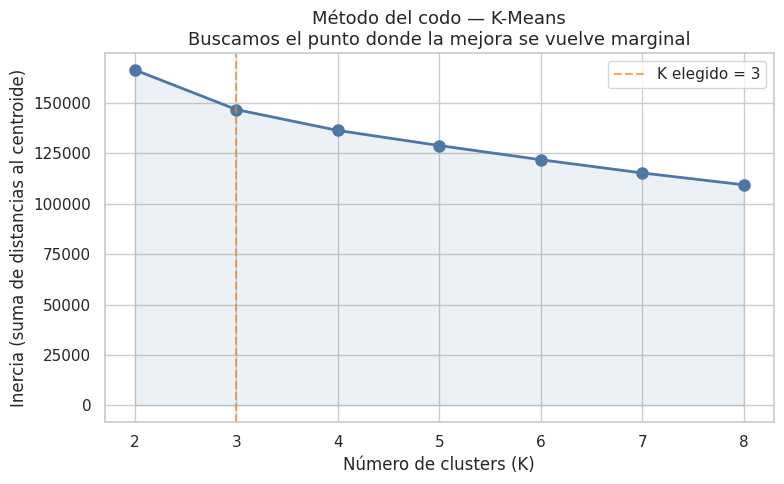


💡 El 'codo' se ve como un cambio brusco en la pendiente de la curva.
   Después del codo, agregar más clusters mejora poco la inercia.


In [ ]:
# ==========================================
# PASO 8B — MÉTODO DEL CODO PARA DETERMINAR K ÓPTIMO
# ==========================================
# Ejecutamos K-Means para K = 2 hasta 8 y graficamos la inercia.
# La inercia mide la suma de distancias cuadradas de cada punto a su centroide.
# Al aumentar K, la inercia siempre baja; buscamos el "codo" donde la mejora se vuelve marginal.

print("Calculando inercia para K = 2 a 8... (puede tardar 1-2 minutos)")

inertias = []
ks = range(2, 9)

for k in ks:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,      # Ejecuta el algoritmo 10 veces con inicializaciones distintas
        max_iter=300    # Máximo de iteraciones por ejecución
    )
    km.fit(X_processed_dense)
    inertias.append(km.inertia_)
    print(f"   K={k}: Inercia = {km.inertia_:,.0f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(ks), inertias, marker='o', linewidth=2, markersize=8, color='#4C78A8')
ax.fill_between(list(ks), inertias, alpha=0.1, color='#4C78A8')

# Marcamos el K que parece el codo (usaremos K=3)
ax.axvline(x=3, color='#F58518', linestyle='--', alpha=0.7, label='K elegido = 3')

ax.set_title('Método del codo — K-Means\nBuscamos el punto donde la mejora se vuelve marginal', fontsize=13)
ax.set_xlabel('Número de clusters (K)')
ax.set_ylabel('Inercia (suma de distancias al centroide)')
ax.set_xticks(list(ks))
ax.legend()
plt.tight_layout()
plt.show()

print()
print("💡 El 'codo' se ve como un cambio brusco en la pendiente de la curva.")
print("   Después del codo, agregar más clusters mejora poco la inercia.")


✅ K-Means ejecutado con K=3
   Sesiones por cluster: {np.int32(0): np.int64(1615), np.int32(1): np.int64(9658), np.int32(2): np.int64(1057)}

PCA: varianza explicada por componente 1: 22.2%
PCA: varianza explicada por componente 2: 11.0%
PCA: varianza total explicada en 2D:       33.2%

=== Resumen de cada cluster ===


,Sesiones,Tasa_compra,PageValues_prom,ProductPages_prom,BounceRate_prom,ExitRate_prom
cluster,,,,,,
0,"1,615",28.0%,9.668000,96.963000,0.006000,0.019000
1,"9,658",15.0%,5.902000,23.956000,0.009000,0.032000
2,"1,057",0.6%,0.000000,3.109000,0.166000,0.180000


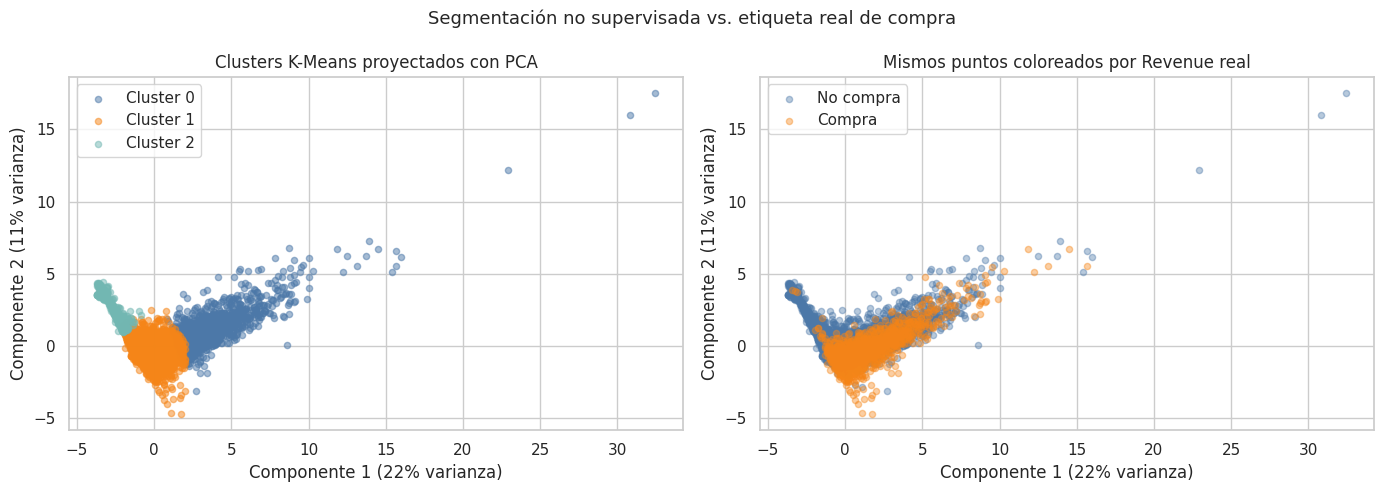

In [ ]:
# ==========================================
# PASO 8C — K-MEANS CON K=3 Y VISUALIZACIÓN PCA
# ==========================================
# Aplicamos K-Means con K=3 (basado en el método del codo).
# Luego usamos PCA para proyectar los datos a 2 dimensiones y visualizar los clusters.

k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_processed_dense)

print(f"✅ K-Means ejecutado con K={k_optimo}")
print(f"   Sesiones por cluster: {dict(zip(*np.unique(clusters, return_counts=True)))}")
print()

# ── Reducción de dimensionalidad con PCA ──────────────────────────────────
# PCA proyecta los datos de N dimensiones a 2 dimensiones
# para poder visualizarlos en un plano 2D.
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_processed_dense)

print(f"PCA: varianza explicada por componente 1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PCA: varianza explicada por componente 2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"PCA: varianza total explicada en 2D:       {pca.explained_variance_ratio_.sum()*100:.1f}%")
print()

# ── Tabla resumen de cada cluster ─────────────────────────────────────────
cluster_df = df.copy()
cluster_df['cluster']      = clusters
cluster_df['Revenue_int']  = y  # Variable objetivo como entero para calcular tasas

cluster_summary = cluster_df.groupby('cluster').agg(
    Sesiones          = ('Revenue_int', 'size'),
    Tasa_compra       = ('Revenue_int', 'mean'),
    PageValues_prom   = ('PageValues', 'mean'),
    ProductPages_prom = ('ProductRelated', 'mean'),
    BounceRate_prom   = ('BounceRates', 'mean'),
    ExitRate_prom     = ('ExitRates', 'mean')
).round(3)

print("=== Resumen de cada cluster ===")
display(cluster_summary.style
    .background_gradient(subset=['Tasa_compra'], cmap='RdYlGn')
    .format({'Tasa_compra': '{:.1%}', 'Sesiones': '{:,}'})
)

# ── Visualización 2D ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: coloreado por cluster
palette_clusters = {0: '#4C78A8', 1: '#F58518', 2: '#72B7B2'}
for c in range(k_optimo):
    mask = clusters == c
    axes[0].scatter(coords[mask, 0], coords[mask, 1],
                    c=palette_clusters[c], label=f'Cluster {c}', alpha=0.5, s=20)
axes[0].set_title('Clusters K-Means proyectados con PCA', fontsize=12)
axes[0].set_xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]*100:.0f}% varianza)')
axes[0].set_ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]*100:.0f}% varianza)')
axes[0].legend()

# Panel derecho: coloreado por Revenue real (para comparar)
for rev, color, label in [(0, '#4C78A8', 'No compra'), (1, '#F58518', 'Compra')]:
    mask = y.values == rev
    axes[1].scatter(coords[mask, 0], coords[mask, 1],
                    c=color, label=label, alpha=0.4, s=20)
axes[1].set_title('Mismos puntos coloreados por Revenue real', fontsize=12)
axes[1].set_xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]*100:.0f}% varianza)')
axes[1].set_ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]*100:.0f}% varianza)')
axes[1].legend()

plt.suptitle('Segmentación no supervisada vs. etiqueta real de compra', fontsize=13)
plt.tight_layout()
plt.show()


### ✏️ Responde las preguntas guía del Paso 8

1. **¿En qué valor de K se ve el "codo" más claro en tu gráfica?**  
   *...*

2. **¿Cuál de los 3 clusters tiene mayor tasa de compra? ¿Qué otras características lo distinguen?**  
   *...*

3. **¿Qué porcentaje de varianza explican las 2 componentes de PCA? ¿Te parece suficiente?**  
   *...*

4. **¿Cómo podrías usar estos clusters en una estrategia de marketing o en el aula?**  
   *...*


---
## Paso 9 — Registro con MLflow y exportación del pipeline

### ¿Por qué registrar experimentos?
En un proyecto real entrenas docenas de modelos con diferentes configuraciones.  
Sin registro, es imposible recordar qué configuración dio qué resultado.

**MLflow** permite registrar:
- Parámetros del modelo (hiperparámetros).
- Métricas de evaluación (ROC-AUC, F1, etc.).
- El modelo serializado para poder cargarlo después.

### ¿Qué es Pickle?
`pickle` serializa objetos Python a un archivo binario (`.pkl`).  
El pipeline exportado incluye el **preprocesador ajustado + el modelo entrenado**.  
Para hacer predicciones en producción, solo necesitas cargar el archivo `.pkl` y llamar a `predict()`.

**Importante:** al guardar el Pipeline completo, te aseguras de que las predicciones en producción apliquen exactamente las mismas transformaciones que en el entrenamiento.


In [ ]:
# ==========================================
# PASO 9A — REGISTRO DEL EXPERIMENTO CON MLFLOW
# ==========================================
# MLflow registra el experimento localmente en la carpeta 'mlruns'.
# En producción, se conectaría a un servidor MLflow compartido.

import mlflow
import mlflow.sklearn

# Creamos o seleccionamos el experimento
mlflow.set_experiment('M2_online_shoppers_ml')

print("Registrando experimento en MLflow...")

with mlflow.start_run(run_name='random_forest_pipeline_optimizado'):
    # 1. Registramos los hiperparámetros que usó el mejor modelo
    mlflow.log_params(search.best_params_)

    # 2. Registramos las métricas del conjunto de prueba
    mlflow.log_metric('roc_auc_test', roc_auc_score(y_test, final_proba))
    mlflow.log_metric('f1_test',      f1_score(y_test, final_pred))
    mlflow.log_metric('recall_test',  recall_score(y_test, final_pred))
    mlflow.log_metric('roc_auc_cv',   search.best_score_)

    # 3. Guardamos el modelo completo (pipeline) en MLflow
    # Usamos cloudpickle para evitar problemas de compatibilidad con versiones
    mlflow.sklearn.log_model(
        sk_model=modelo_final,
        name='pipeline_revenue_predictor',
        serialization_format='cloudpickle'
    )

print("✅ Experimento registrado en MLflow.")
print()
print("El registro incluye:")
print("   • Hiperparámetros del mejor modelo")
print("   • Métricas de evaluación (train y test)")
print("   • Pipeline serializado")


2026/06/24 23:47:15 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/24 23:47:15 INFO mlflow.store.db.utils: Updating database tables
2026/06/24 23:47:17 INFO mlflow.tracking.fluent: Experiment with name 'M2_online_shoppers_ml' does not exist. Creating a new experiment.


Registrando experimento en MLflow...


2026/06/24 23:47:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Experimento registrado en MLflow.

El registro incluye:
   • Hiperparámetros del mejor modelo
   • Métricas de evaluación (train y test)
   • Pipeline serializado


In [ ]:
# ==========================================
# PASO 9B — EXPORTACIÓN DEL PIPELINE CON PICKLE
# ==========================================
# Además de MLflow, exportamos el pipeline con Pickle
# para usarlo directamente en la API FastAPI del Paso 10.

# Creamos la carpeta 'artifacts' si no existe
Path('artifacts').mkdir(exist_ok=True)

# Guardamos el pipeline completo (preprocesador + modelo) en un archivo .pkl
with open('artifacts/modelo_revenue_pipeline.pkl', 'wb') as f:
    pickle.dump(modelo_final, f)

print("✅ Pipeline exportado en: artifacts/modelo_revenue_pipeline.pkl")

# ── Generamos un ejemplo de payload para probar la API ─────────────────
# Tomamos la primera fila del conjunto de prueba como ejemplo real
sample_input   = X_test.iloc[[0]].copy()
sample_payload = sample_input.iloc[0].to_dict()

# Convertimos tipos de datos no serializables (bool numpy → bool Python)
for k, v in sample_payload.items():
    if isinstance(v, (np.bool_, np.integer)):
        sample_payload[k] = int(v) if isinstance(v, np.integer) else bool(v)
    elif isinstance(v, np.floating):
        sample_payload[k] = float(v)

with open('artifacts/sample_payload.json', 'w', encoding='utf-8') as f:
    json.dump(sample_payload, f, ensure_ascii=False, indent=2)

print("✅ Ejemplo de payload exportado en: artifacts/sample_payload.json")
print()
print("=== Payload de ejemplo (primera sesión del conjunto de prueba) ===")
print(json.dumps(sample_payload, indent=2, ensure_ascii=False))

# ── Verificación: cargar el modelo desde disco y hacer una predicción ───
print()
print("Verificando que el modelo cargado desde disco funciona correctamente...")
with open('artifacts/modelo_revenue_pipeline.pkl', 'rb') as f:
    modelo_cargado = pickle.load(f)

pred_prueba = modelo_cargado.predict(sample_input)[0]
proba_prueba = modelo_cargado.predict_proba(sample_input)[0, 1]
print(f"   Predicción: {'COMPRA' if pred_prueba == 1 else 'No compra'}")
print(f"   Probabilidad de compra: {proba_prueba:.4f}")
print("✅ El modelo cargado desde disco funciona correctamente.")


✅ Pipeline exportado en: artifacts/modelo_revenue_pipeline.pkl
✅ Ejemplo de payload exportado en: artifacts/sample_payload.json

=== Payload de ejemplo (primera sesión del conjunto de prueba) ===
{
  "Administrative": 1,
  "Administrative_Duration": 4.0,
  "Informational": 0,
  "Informational_Duration": 0.0,
  "ProductRelated": 13,
  "ProductRelated_Duration": 161.1666667,
  "BounceRates": 0.024615385,
  "ExitRates": 0.061538462,
  "PageValues": 0.0,
  "SpecialDay": 0.6,
  "Month": "May",
  "OperatingSystems": 2,
  "Browser": 5,
  "Region": 9,
  "TrafficType": 5,
  "VisitorType": "Returning_Visitor",
  "Weekend": false
}

Verificando que el modelo cargado desde disco funciona correctamente...
   Predicción: No compra
   Probabilidad de compra: 0.0415
✅ El modelo cargado desde disco funciona correctamente.


---
## Paso 10 — Despliegue mínimo con FastAPI: endpoint `/predict`

### ¿Por qué desplegar el modelo como API?
Un modelo en un notebook solo puede usarlo quien tiene acceso al notebook.  
Una **API REST** permite que cualquier sistema (frontend web, app móvil, CRM) consulte el modelo enviando una petición HTTP.

### ¿Qué es FastAPI?
FastAPI es un framework de Python para construir APIs web de forma rápida.  
Genera automáticamente documentación interactiva (Swagger UI) en `/docs`.

### Flujo de una predicción via API:
```
[Cliente] ──POST /predict──▶ [FastAPI] ──▶ [Pipeline] ──▶ ─predict_proba()─▶ [Respuesta JSON]
   Envía JSON con          Valida el        Preprocesa    Calcula probabilidad   Devuelve predicción
   variables de la sesión  esquema          + predice     de compra              y decisión
```

### Conceptos clave
- **Endpoint:** URL que expone una funcionalidad de la API (`/predict`).
- **Método POST:** el cliente envía datos en el cuerpo de la petición.
- **Pydantic BaseModel:** define y valida automáticamente el esquema de los datos de entrada.
- **TestClient:** cliente de prueba que simula peticiones HTTP sin levantar un servidor real.


In [ ]:
# ==========================================
# PASO 10A — ESCRITURA DEL CÓDIGO DE LA API (app.py)
# ==========================================
# %%writefile escribe el contenido de la celda en el archivo app.py
# Este archivo define la API FastAPI con un endpoint POST /predict

%%writefile app.py
"""
API de predicción de intención de compra en e-commerce.
Modelo: Random Forest optimizado (Pipeline Scikit-learn)
Dataset: Online Shoppers Purchasing Intention (UCI ML Repository)
"""
import pickle
from typing import Any, Dict

import pandas as pd
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field

# ── Carga del modelo al iniciar la API ─────────────────────────────────
# El modelo se carga UNA SOLA VEZ cuando arranca la API, no en cada petición.
# Esto hace que las predicciones sean rápidas (no hay overhead de carga).
try:
    with open('artifacts/modelo_revenue_pipeline.pkl', 'rb') as f:
        model = pickle.load(f)
except FileNotFoundError:
    raise RuntimeError("No se encontró el archivo del modelo. Ejecuta primero el Paso 9.")

# ── Definición de la aplicación FastAPI ────────────────────────────────
app = FastAPI(
    title='🛒 Online Shoppers Revenue Predictor',
    description=(
        'API para predecir si una sesión de e-commerce terminará en compra.\n\n'
        'Modelo: Random Forest optimizado con datos del UCI ML Repository.\n'
        'Envía un POST a /predict con las variables de la sesión y obtendrás '
        'la probabilidad de compra y una recomendación de acción.'
    ),
    version='1.0.0'
)

# ── Esquema de entrada (Pydantic valida automáticamente los tipos) ──────
class SessionFeatures(BaseModel):
    """Variables de una sesión de navegación en la tienda en línea."""
    Administrative:           float = Field(..., description="Páginas administrativas visitadas")
    Administrative_Duration:  float = Field(..., description="Tiempo en páginas administrativas (seg)")
    Informational:            float = Field(..., description="Páginas informativas visitadas")
    Informational_Duration:   float = Field(..., description="Tiempo en páginas informativas (seg)")
    ProductRelated:           float = Field(..., description="Páginas de producto visitadas")
    ProductRelated_Duration:  float = Field(..., description="Tiempo en páginas de producto (seg)")
    BounceRates:              float = Field(..., description="Tasa de rebote promedio [0-1]")
    ExitRates:                float = Field(..., description="Tasa de salida promedio [0-1]")
    PageValues:               float = Field(..., description="Valor promedio de páginas visitadas")
    SpecialDay:               float = Field(..., description="Cercanía a día especial [0-1]")
    Month:                    str   = Field(..., description="Mes de la sesión (ej. 'Nov', 'Dec')")
    OperatingSystems:         int   = Field(..., description="Sistema operativo del visitante")
    Browser:                  int   = Field(..., description="Navegador del visitante")
    Region:                   int   = Field(..., description="Región geográfica")
    TrafficType:              int   = Field(..., description="Tipo de tráfico que originó la visita")
    VisitorType:              str   = Field(..., description="'Returning_Visitor', 'New_Visitor', 'Other'")
    Weekend:                  bool  = Field(..., description="True si la visita fue en fin de semana")

# ── Endpoints ───────────────────────────────────────────────────────────
@app.get('/', summary='Health check')
def home():
    """Verifica que la API está funcionando."""
    return {'status': 'ok', 'mensaje': 'API lista. Usa POST /predict para predecir.', 'docs': '/docs'}

@app.post('/predict', summary='Predecir intención de compra')
def predict(features: SessionFeatures) -> Dict[str, Any]:
    """
    Recibe las variables de una sesión y predice la probabilidad de compra.

    Retorna:
    - prediccion_compra: True si el modelo predice que la sesión terminará en compra
    - probabilidad_compra: probabilidad estimada [0.0 - 1.0]
    - decision: acción recomendada según la predicción
    - umbral_usado: umbral de decisión aplicado (0.50 por defecto)
    """
    try:
        # Convertimos el objeto Pydantic a DataFrame de una sola fila
        # El pipeline espera un DataFrame con los nombres de columnas originales
        row = pd.DataFrame([features.dict()])

        # Aplicamos el pipeline: preprocesa y predice en un solo paso
        proba = float(model.predict_proba(row)[0, 1])  # P(Revenue=True)
        pred  = bool(proba >= 0.50)                    # Umbral de clasificación

        return {
            'prediccion_compra':   pred,
            'probabilidad_compra': round(proba, 4),
            'decision': (
                '🎯 Priorizar: mostrar oferta personalizada o asistencia en tiempo real'
                if pred else
                '📊 Mantener experiencia estándar; monitorear engagement'
            ),
            'umbral_usado': 0.50
        }
    except Exception as e:
        raise HTTPException(status_code=422, detail=f"Error al procesar la predicción: {str(e)}")


Writing app.py


In [ ]:
# ==========================================
# PASO 10B — PRUEBA LOCAL DEL ENDPOINT SIN SERVIDOR EXTERNO
# ==========================================
# TestClient simula peticiones HTTP directamente sobre la app FastAPI.
# Esto permite probar la API sin necesidad de levantar un servidor real.
# Es la forma recomendada de probar FastAPI en entornos como Colab.

from fastapi.testclient import TestClient
from app import app  # Importamos la app que definimos en la celda anterior

client = TestClient(app)

# ── Prueba 1: Health check ─────────────────────────────────────────────
print("=== Prueba 1: GET / (Health check) ===")
response_home = client.get('/')
print(f"   Status code: {response_home.status_code}")
print(f"   Respuesta:   {response_home.json()}")
print()

# ── Prueba 2: POST /predict con el payload real del dataset ───────────
print("=== Prueba 2: POST /predict con payload real del dataset ===")
print("Payload enviado (primera sesión del conjunto de prueba):")
print(json.dumps(sample_payload, indent=2, ensure_ascii=False))
print()

response_pred = client.post('/predict', json=sample_payload)
print(f"Status code: {response_pred.status_code}")
print()
print("Respuesta de la API:")
respuesta = response_pred.json()
for k, v in respuesta.items():
    print(f"   {k}: {v}")

print()
print("💡 Cómo interpretar la respuesta:")
print(f"   • prediccion_compra = {respuesta['prediccion_compra']}:")
print(f"     El modelo {'PREDICE que esta sesión terminará en compra' if respuesta['prediccion_compra'] else 'NO predice compra en esta sesión'}")
print(f"   • probabilidad_compra = {respuesta['probabilidad_compra']}:")
print(f"     El modelo asigna un {respuesta['probabilidad_compra']*100:.1f}% de probabilidad de que ocurra una compra")
print(f"   • decision = '{respuesta['decision']}':")
print(f"     Acción recomendada para el equipo de marketing/UX")


=== Prueba 1: GET / (Health check) ===
   Status code: 200
   Respuesta:   {'status': 'ok', 'mensaje': 'API lista. Usa POST /predict para predecir.', 'docs': '/docs'}

=== Prueba 2: POST /predict con payload real del dataset ===
Payload enviado (primera sesión del conjunto de prueba):
{
  "Administrative": 1,
  "Administrative_Duration": 4.0,
  "Informational": 0,
  "Informational_Duration": 0.0,
  "ProductRelated": 13,
  "ProductRelated_Duration": 161.1666667,
  "BounceRates": 0.024615385,
  "ExitRates": 0.061538462,
  "PageValues": 0.0,
  "SpecialDay": 0.6,
  "Month": "May",
  "OperatingSystems": 2,
  "Browser": 5,
  "Region": 9,
  "TrafficType": 5,
  "VisitorType": "Returning_Visitor",
  "Weekend": false
}

Status code: 200

Respuesta de la API:
   prediccion_compra: False
   probabilidad_compra: 0.0415
   decision: 📊 Mantener experiencia estándar; monitorear engagement
   umbral_usado: 0.5

💡 Cómo interpretar la respuesta:
   • prediccion_compra = False:
     El modelo NO predice c

In [ ]:
# ==========================================
# PASO 10C — DEMO EN VIVO CON NGROK (OPCIONAL)
# ==========================================
# Esta celda levanta la API en un servidor público temporal usando ngrok.
# Cualquier persona con el URL podrá hacer peticiones a tu API.
#
# INSTRUCCIONES:
#   1. Crea una cuenta gratuita en https://ngrok.com
#   2. Copia tu token de autenticación desde el dashboard de ngrok
#   3. Reemplaza 'TU_TOKEN_AQUI' con tu token real
#   4. Ejecuta esta celda
#   5. Abre la URL de Swagger (/docs) en un navegador
#   6. Para detener: presiona el botón STOP de la celda o Ctrl+C
#
# NOTA: Si NO tienes token de ngrok, puedes omitir esta celda.
# La API ya fue probada correctamente con TestClient en la celda anterior.

import nest_asyncio
from pyngrok import ngrok
import uvicorn
from app import app

NGROK_TOKEN = "TU_TOKEN_AQUI"  # ← Reemplaza con tu token de ngrok

if NGROK_TOKEN != "TU_TOKEN_AQUI":
    ngrok.set_auth_token(NGROK_TOKEN)
    nest_asyncio.apply()

    try:
        ngrok.kill()  # Cierra tuneles previos si los hay
    except:
        pass

    public_url = ngrok.connect(8000)

    print("=" * 60)
    print("🚀 ¡API desplegada exitosamente!")
    print(f"🔗 URL pública:   {public_url.public_url}")
    print(f"📖 Swagger Docs:  {public_url.public_url}/docs")
    print(f"🧪 Prueba rápida: {public_url.public_url}/")
    print("=" * 60)
    print("Para detener el servidor: presiona el botón STOP de esta celda.")
    print()

    config = uvicorn.Config(app, host='0.0.0.0', port=8000, log_level="info")
    server = uvicorn.Server(config)
    await server.serve()
else:
    print("ℹ️  Celda de ngrok omitida.")
    print("   Si deseas hacer la demo pública, reemplaza 'TU_TOKEN_AQUI' con tu token de ngrok.")
    print("   La API fue probada correctamente con TestClient en la celda anterior.")


INFO:     Started server process [21960]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


🚀 ¡API desplegada exitosamente!
🔗 URL pública:   https://confusing-everyone-activism.ngrok-free.dev
📖 Swagger Docs:  https://confusing-everyone-activism.ngrok-free.dev/docs
🧪 Prueba rápida: https://confusing-everyone-activism.ngrok-free.dev/
Para detener el servidor: presiona el botón STOP de esta celda.

INFO:     2605:59c8:71ef:2308:1c5a:e775:6303:ada9:0 - "GET / HTTP/1.1" 200 OK
INFO:     2605:59c8:71ef:2308:1c5a:e775:6303:ada9:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     2605:59c8:71ef:2308:1c5a:e775:6303:ada9:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     2605:59c8:71ef:2308:1c5a:e775:6303:ada9:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     2605:59c8:71ef:2308:1c5a:e775:6303:ada9:0 - "POST /predict HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [21960]


### ✏️ Responde las preguntas guía del Paso 10

1. **¿Qué datos espera recibir el endpoint `/predict`? ¿Qué pasa si faltan campos?**  
   *...*

2. **¿Cómo interpretarías una respuesta con `probabilidad_compra = 0.72`? ¿Qué acción tomarías?**  
   *...*

3. **¿Qué validaciones o controles agregarías antes de publicar esta API en un entorno real de producción?**  
   *...*

4. **¿Cómo podrías ajustar el umbral de 0.50 para maximizar el Recall? ¿Qué sacrificarías?**  
   *...*


---
##  Checklist del entregable final

Antes de entregar tu libreta, verifica que cumple con todo lo siguiente:

### Ejecución
- [ ] La libreta ejecuta de inicio a fin sin modificar ninguna celda.
- [ ] No hay celdas con errores (✗) — solo salidas correctas o celdas de texto.

### Contenido técnico
- [ ] Tabla comparativa de al menos 3 modelos con métricas completas (Paso 5).
- [ ] Curvas ROC de los tres modelos en una sola gráfica (Paso 5).
- [ ] Matriz de confusión y reporte de clasificación del mejor modelo (Paso 5).
- [ ] Árbol de decisión visualizado (Paso 6).
- [ ] Gráfica de importancia de variables con al menos 15 variables (Paso 6).
- [ ] Resultados de validación cruzada 5-fold con media ± desviación estándar (Paso 7).
- [ ] Gráfica del método del codo (Paso 8).
- [ ] Visualización PCA 2D con clusters coloreados (Paso 8).
- [ ] Tabla resumen de clusters con tasa de compra (Paso 8).
- [ ] Pipeline exportado como `.pkl` (Paso 9).
- [ ] API FastAPI probada con TestClient y payload real (Paso 10).

### Reflexión (preguntas guía)
- [ ] Todas las secciones de "Responde las preguntas guía" tienen respuestas escritas.

---
##  Insight final — Tres conclusiones accionables

### Insight 1 — Sobre el modelo
> *¿Qué aprendiste sobre los algoritmos comparados? ¿Cuál usarías en producción y por qué?*

*Escribe aquí...*

### Insight 2 — Sobre las variables
> *¿Qué variables son más predictivas de la intención de compra? ¿Qué implicaciones tiene eso para el negocio?*

*Escribe aquí...*

### Insight 3 — Sobre despliegue y transferencia pedagógica
> *¿Cómo podrías aplicar este flujo (dataset → pipeline → API) en una asignatura que impartes?*
> *¿Qué parte del flujo priorizarías enseñar a tus estudiantes y por qué?*

*Escribe aquí...*

---
##  Ficha de transferencia pedagógica

Completa esta ficha para cerrar la sesión:

| Campo | Tu respuesta |
|-------|-------------|
| **Materia donde aplicarías esto** | *...* |
| **Problema del mundo real** | *...* |
| **Dataset que usarías** | *...* |
| **Modelo seleccionado y justificación** | *...* |
| **Entregable que pedirías a tus estudiantes** | *...* |
| **Métrica principal de evaluación del modelo** | *...* |

---
*Sesión 2 de 4 — Machine Learning: Selección, Entrenamiento, Evaluación y Despliegue*  
*Dr. Omar Jehovani López Orozco | TecNM Campus Apatzingán | Junio 2026*
